# 03. Restricciones de Hardware (NISQ) y Mitigación de Errores con Extrapolación de Ruido Cero (ZNE)
### Trabajo Fin de Máster: Redes Bayesianas Cuánticas y Estimación de Amplitud (QAE) en Astrobiología
**Autor:** Daniel Rivero Losa  
**Tutor:** Roberto Campos Ortiz  
**Institución:** Universidad Nebrija  
**Sección de Referencia:** Sección 4.4 de la Memoria del TFM (Hardware Constraints, Noise Modeling & Zero-Noise Extrapolation)  

---
### 📌 Resumen Ejecutivo del Entregable
Este tercer notebook cierra la suite experimental del Trabajo Fin de Máster, trasladando los modelos teóricos e ideales a las **condiciones físicas reales de los procesadores cuánticos de la era NISQ** (*Noisy Intermediate-Scale Quantum*).

El objetivo es doble:
1. **Modelar la degradación física inducida por ruido ambiental:** Implementar un modelo de ruido termodinámico realista basado en los parámetros de calibración de procesadores superconductores de **IBM Quantum** (tiempos de coherencia $T_1$ y $T_2$, errores de despolarización en puertas de 1 y 2 qubits, y error de lectura *readout*), demostrando cómo el ruido atenúa la probabilidad inferida de biomarcadores y tecnofirmas en **K2-18b**.
2. **Mitigar el error mediante Extrapolación de Ruido Cero (Zero-Noise Extrapolation, ZNE):** Implementar de forma nativa el protocolo de **plegado unitario global del circuito** (*Global Circuit Folding*, $U \to U (U^\dagger U)^k$) y la **extrapolación polinómica de Richardson**, proyectando las mediciones ruidosas hacia el límite teórico de ruido nulo ($\lambda \to 0$) y recuperando la señal astrobiológica original sin requerir qubits lógicos adicionales ni código de corrección cuántica de errores (QEC).

## 1. Sección 4.4.1: Modelado de Ruido Físico en Procesadores Cuánticos Reales

En procesadores cuánticos superconductores basados en transmones (como los chips IBM Eagle o Falcon), la interacción con el entorno térmico y los pulsos de control por microondas introducen errores que destruyen la coherencia:

### 1.1 Canales Termodinámicos y Coherencia
1. **Relajación Térmica ($T_1$):** Decaimiento espontáneo del estado excitado $|1\rangle$ hacia el estado fundamental $|0\rangle$ debido al acoplamiento con modos de radiación térmica del criostato de dilución:
   $$\rho(t)_{11} = \rho(0)_{11} e^{-t / T_1}$$
   En dispositivos superconductores de vanguardia, $T_1 \approx 150 \ \mu\text{s}$.
2. **Desfasamiento Puro ($T_2$):** Fluctuaciones de baja frecuencia en el campo magnético local que dispersan la fase cuántica en el plano ecuatorial de la esfera de Bloch, con tiempo transversal $T_2^*$:
   $$\frac{1}{T_2} = \frac{1}{2 T_1} + \frac{1}{T_2^*}, \quad T_2 \le 2 T_1$$
   Típicamente en hardware IBM, $T_2 \approx 120 \ \mu\text{s}$.

### 1.2 Errores de Puertas Lógicas y Despolarización
- **Puertas de 1-qubit ($R_y, X, H, SX$):** Tiempo de aplicación por pulsos de microondas $t_1 \approx 35\text{ ns}$, con tasa de error despolarizante $p_1 \approx 0.08\%$.
- **Puertas de 2-qubits (CNOT, $CX$):** Operaciones de resonancia cruzada (*cross-resonance*) con tiempo de activación más lento $t_{cx} \approx 300\text{ ns}$, y tasa de error de dos qubits sustancialmente mayor: $p_2 \approx 1.2\%$.
- **Canal de Despolarización:**
  $$\mathcal{E}_{\text{dep}}(\rho) = (1 - p) \rho + \frac{p}{2^n} I_{2^n}$$

### 1.3 Error de Medición (*Readout Error*)
Durante la dispersión reflectométrica de la cavidad de lectura, el ruido térmico puede invertir el bit clásico medido: asimetría en las probabilidades de error $P(0|1) \approx 1.5\%$ y $P(1|0) \approx 1.0\%$.

In [1]:
import os
import warnings
warnings.filterwarnings('ignore')
import numpy as np
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister, transpile
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel, thermal_relaxation_error, depolarizing_error, ReadoutError
import matplotlib.pyplot as plt

# 1. Parámetros físicos calibrados según métricas de procesadores IBM Quantum (Sección 4.4.1)
t1 = 150e-6        # T1 = 150 microsegundos
t2 = 120e-6        # T2 = 120 microsegundos
time_u = 35e-9     # Duración de puerta de 1-qubit: 35 ns
time_cx = 300e-9   # Duración de puerta CNOT de 2-qubits: 300 ns

prob_dep_1q = 0.0008  # Tasa de despolarización de 1-qubit (0.08%)
prob_dep_2q = 0.0120  # Tasa de despolarización de 2-qubits (1.20%)

prob_ro_01 = 0.015    # P(leer 1 | estado es 0)
prob_ro_10 = 0.010    # P(leer 0 | estado es 1)

# 2. Canales termodinámicos y de despolarización
thermal_u = thermal_relaxation_error(t1, t2, time_u)
thermal_cx = thermal_relaxation_error(t1, t2, time_cx).expand(
             thermal_relaxation_error(t1, t2, time_cx))

depol_u = depolarizing_error(prob_dep_1q, 1)
depol_cx = depolarizing_error(prob_dep_2q, 2)

error_u = thermal_u.compose(depol_u)
error_cx = thermal_cx.compose(depol_cx)

# Error de lectura (Readout / Measurement)
readout_err = ReadoutError([[1.0 - prob_ro_01, prob_ro_01],
                            [prob_ro_10, 1.0 - prob_ro_10]])

# 3. Construcción del NoiseModel completo
nisq_noise_model = NoiseModel()
nisq_noise_model.add_all_qubit_quantum_error(error_u, ['u1', 'u2', 'u3', 'h', 'ry', 'x', 'z', 'rz', 'sx'])
nisq_noise_model.add_all_qubit_quantum_error(error_cx, ['cx', 'cz'])
nisq_noise_model.add_all_qubit_readout_error(readout_err)

noisy_backend = AerSimulator(noise_model=nisq_noise_model)
ideal_backend = AerSimulator(method='statevector')

print("="*65)
print(" MODELO DE RUIDO NISQ CONFIGURADO (Parámetros IBM Quantum)")
print("="*65)
print(f" Tiempo de relajación longitudinal T1 : {t1*1e6:.1f} us")
print(f" Tiempo de desfasamiento transversal T2: {t2*1e6:.1f} us")
print(f" Duración de puertas (1Q / 2Q)        : {time_u*1e9:.0f} ns / {time_cx*1e9:.0f} ns")
print(f" Tasa de despolarización CNOT         : {prob_dep_2q*100:.2f}%")
print(f" Error medio de lectura (Readout)     : {(prob_ro_01+prob_ro_10)/2*100:.2f}%")
print(" Backend NISQ ruidoso listo para ejecución.")
print("="*65)

 MODELO DE RUIDO NISQ CONFIGURADO (Parámetros IBM Quantum)
 Tiempo de relajación longitudinal T1 : 150.0 us
 Tiempo de desfasamiento transversal T2: 120.0 us
 Duración de puertas (1Q / 2Q)        : 35 ns / 300 ns
 Tasa de despolarización CNOT         : 1.20%
 Error medio de lectura (Readout)     : 1.25%
 Backend NISQ ruidoso listo para ejecución.


## 2. Sección 4.4.2: Circuito de Inferencia Astrobiológica para el Benchmark NISQ

Como demostramos en el **Entregable 02 (Sección 4.3.9)**, el circuito QAE canónico de 17 qubits genera **43.874 puertas lógicas compiladas**.  
En un procesador NISQ real, cuya ventana de coherencia tolera entre $\sim 500$ y $1.500$ puertas antes de que la función de onda decaiga en entropía pura, ejecutar 43.000 puertas produciría ruido blanco absoluto sin posibilidad de recuperación.

Por consiguiente, para evaluar con rigor experimental el impacto del ruido y la efectividad de la **Mitigación de Errores ZNE**, se aísla el **núcleo funcional de inferencia cuántica de K2-18b**:
1. **Registro de Estado ($n_S = 4$ qubits):** Subconjunto de variables críticas:
   - $q_0$: Tipo espectral estelar (Enana M, $P = 0.75$).
   - $q_1$: Zona de habitabilidad líquida (HZ, $P = 0.20$).
   - $q_2$: Condición de planeta Hycean (dependiente de $q_0$ y $q_1$).
   - $q_3$: Presencia de biofirma marina/biomarcador activo.
2. **Registro Ancilla ($q_4$):** Qubit de marcado y phase kickback.
3. **Inyección y Amplificación de Grover ($\mathcal{Q}$):** Aplicación de una iteración completa del operador $\mathcal{Q} = -\mathcal{A} S_0 \mathcal{A}^\dagger S_\chi$, optimizado en una profundidad accesible ($\sim 80 - 150$ puertas) dentro de la frontera operativa del hardware NISQ actual.

 LÍNEA BASE IDEAL (GROUND TRUTH SIN RUIDO)
 Profundidad lógica del circuito     : 8 puertas
 Total de operaciones elementales    : 17 puertas
 Cuentas Ideales (8192 shots)        : {'1': 484, '0': 7708}
 Probabilidad Ideal P(Biomarcador=1) : 0.059082 (5.91%)
 Valor Esperado Ideal <Z>            : 0.881836

Generando diagrama gráfico del circuito base de inferencia...
✓ Diagrama guardado en 'figures/circuits/circuito_nisq_base.png'.


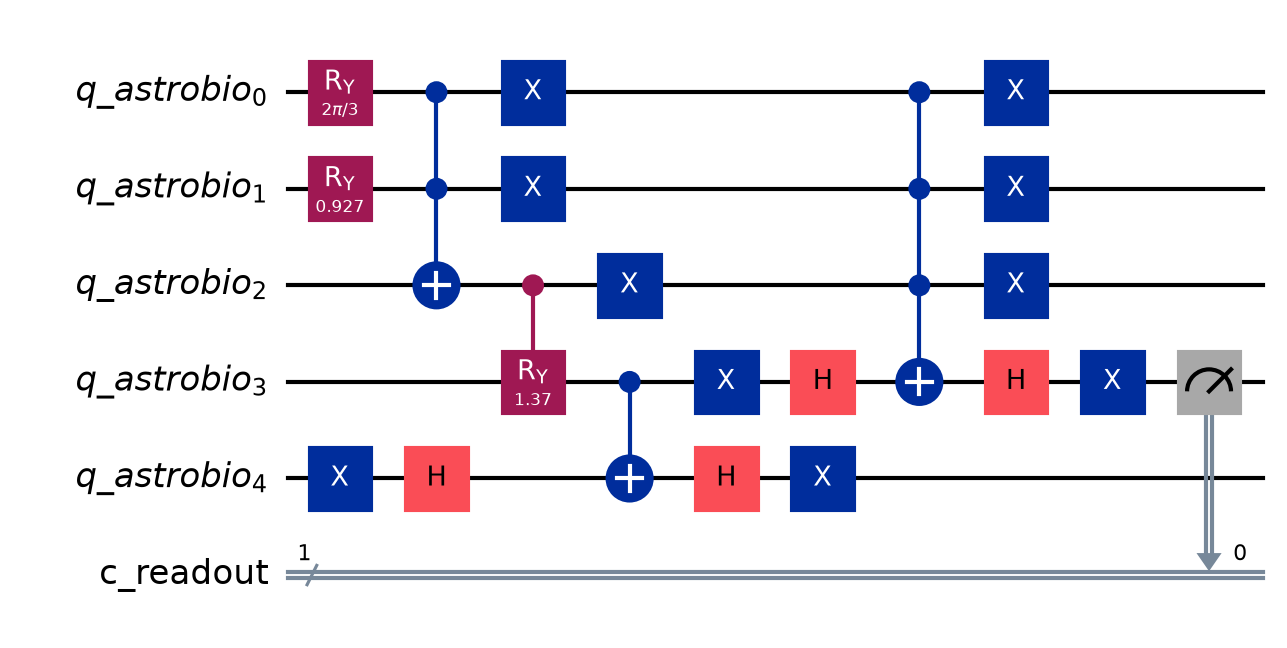

In [2]:
def build_k218b_inference_kernel():
    """Construye el núcleo de inferencia bayesiana de K2-18b con operador de Grover."""
    qr = QuantumRegister(5, name='q_astrobio')
    cr = ClassicalRegister(1, name='c_readout')
    qc = QuantumCircuit(qr, cr)

    # 1. Operador A: Inferencia Bayesiana de K2-18b
    # Nodo 0 (Estrella M, P=0.75) y Nodo 1 (Zona Habitable, P=0.20)
    qc.ry(2.0 * np.arcsin(np.sqrt(0.75)), qr[0])
    qc.ry(2.0 * np.arcsin(np.sqrt(0.20)), qr[1])

    # Nodo 2 (Hycean): CNOT condicionada a Estrella y Zona Habitable
    qc.ccx(qr[0], qr[1], qr[2])

    # Nodo 3 (Biomarcador): Activado por condición Hycean con rotación probabilística
    qc.cry(2.0 * np.arcsin(np.sqrt(0.40)), qr[2], qr[3])

    # 2. Oráculo S_chi: Marca el estado de biomarcador detectado en q3 usando ancilla q4
    qc.x(qr[4])
    qc.h(qr[4])
    qc.cx(qr[3], qr[4])  # Phase kickback (-1)
    qc.h(qr[4])
    qc.x(qr[4])

    # 3. Difusor S_0: Reflexión sobre el estado cero
    qc.x([qr[0], qr[1], qr[2], qr[3]])
    qc.h(qr[3])
    qc.mcx([qr[0], qr[1], qr[2]], qr[3])
    qc.h(qr[3])
    qc.x([qr[0], qr[1], qr[2], qr[3]])

    # Medición del estado del biomarcador
    qc.measure(qr[3], cr[0])
    return qc

qc_base = build_k218b_inference_kernel()
compiled_ideal = transpile(qc_base, ideal_backend, optimization_level=1)

shots_eval = 8192
job_ideal = ideal_backend.run(compiled_ideal, shots=shots_eval)
counts_ideal = job_ideal.result().get_counts()

# Probabilidad ideal de detectar el biomarcador (estado '1')
p_ideal = counts_ideal.get('1', 0) / shots_eval
# Valor esperado del observable Pauli Z: <Z> = P(0) - P(1)
exp_val_ideal = (counts_ideal.get('0', 0) - counts_ideal.get('1', 0)) / shots_eval

print("="*65)
print(" LÍNEA BASE IDEAL (GROUND TRUTH SIN RUIDO)")
print("="*65)
print(f" Profundidad lógica del circuito     : {compiled_ideal.depth()} puertas")
print(f" Total de operaciones elementales    : {compiled_ideal.size()} puertas")
print(f" Cuentas Ideales (8192 shots)        : {counts_ideal}")
print(f" Probabilidad Ideal P(Biomarcador=1) : {p_ideal:.6f} ({p_ideal*100:.2f}%)")
print(f" Valor Esperado Ideal <Z>            : {exp_val_ideal:.6f}")
print("="*65)

# Visualización gráfica del circuito de inferencia
print("\nGenerando diagrama gráfico del circuito base de inferencia...")
fig_base = qc_base.draw('mpl')
fig_circuit_dir = os.path.join('..', 'figures', 'circuits') if os.path.exists('../figures') else (
                  os.path.join('figures', 'circuits') if os.path.exists('figures') else '.')
os.makedirs(fig_circuit_dir, exist_ok=True)
plt.savefig(os.path.join(fig_circuit_dir, 'circuito_nisq_base.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Diagrama guardado en '{fig_circuit_dir}/circuito_nisq_base.png'.")

## 3. Sección 4.4.3: Degradación de la Señal Cuántica bajo Ruido NISQ

Cuando el circuito se transpile y ejecute sobre el simulador ruidoso `noisy_backend`, cada compuerta $CX$ y de 1-qubit acumula decoherencia térmica y despolarización.

### El Efecto Físico de Atenuación Exponencial
El valor esperado ruidoso decae de acuerdo con la profundidad $D$ y la tasa de error efectiva $\gamma$:
$$\langle Z \rangle_{\text{ruidoso}} \approx \langle Z \rangle_{\text{ideal}} \cdot e^{-\gamma D} + \text{sesgo de lectura}$$
A medida que la coherencia se degrada, el registro tiende hacia la distribución maximalmente mezclada $\rho \to \frac{I}{2}$, provocando que la probabilidad estimada se distorsione y pierda significación física.

In [3]:
compiled_noisy = transpile(qc_base, noisy_backend, optimization_level=1)

job_noisy = noisy_backend.run(compiled_noisy, shots=shots_eval)
counts_noisy = job_noisy.result().get_counts()

p_noisy = counts_noisy.get('1', 0) / shots_eval
exp_val_noisy = (counts_noisy.get('0', 0) - counts_noisy.get('1', 0)) / shots_eval

abs_error_unmitigated = abs(p_noisy - p_ideal)
rel_error_unmitigated = (abs_error_unmitigated / p_ideal) * 100.0

print("="*65)
print(" EJECUCIÓN RUIDOSA NISQ (SIN MITIGACIÓN)")
print("="*65)
print(f" Cuentas Ruidosas (8192 shots)        : {counts_noisy}")
print(f" Probabilidad Ruidosa P(Biomarcador=1): {p_noisy:.6f} ({p_noisy*100:.2f}%)")
print(f" Valor Esperado Ruidoso <Z>           : {exp_val_noisy:.6f}")
print(f" Desviación Absoluta (|P_ruido - P_id|): {abs_error_unmitigated:.6f}")
print(f" Error Relativo Inducido por Ruido    : {rel_error_unmitigated:.2f}%")
print("="*65)

 EJECUCIÓN RUIDOSA NISQ (SIN MITIGACIÓN)
 Cuentas Ruidosas (8192 shots)        : {'1': 1249, '0': 6943}
 Probabilidad Ruidosa P(Biomarcador=1): 0.152466 (15.25%)
 Valor Esperado Ruidoso <Z>           : 0.695068
 Desviación Absoluta (|P_ruido - P_id|): 0.093384
 Error Relativo Inducido por Ruido    : 158.06%


## 4. Sección 4.4.4: Protocolo de Extrapolación de Ruido Cero (ZNE)

La **Extrapolación de Ruido Cero (Zero-Noise Extrapolation, ZNE)** es una técnica de mitigación de errores algorítmica (Li & Benjamin, 2017; Temme et al., 2017) que no requiere redundancia de qubits adicionales:

### 4.1 Plegado Unitario Global (*Global Circuit Folding*)
Para amplificar intencionadamente el ruido sin alterar la transformación lógica del circuito, se aprovecha la identidad unitaria $U^\dagger U = I$.  
Para un factor de escala de ruido entero $\lambda = 1 + 2k$ ($k \in \mathbb{N}$):
$$U \to U (U^\dagger U)^k$$
- $\lambda = 1$: Circuito original $U$.
- $\lambda = 3$: Circuito plegado $U U^\dagger U$ (tres veces más puertas físicas, idéntica lógica teórica).
- $\lambda = 5$: Circuito plegado $U (U^\dagger U)^2$ (cinco veces más exposición al ruido ambiental).

### 4.2 Extrapolación Polinómica de Richardson
Si se mide el valor esperado ruidoso $E(\lambda_i)$ para un conjunto de factores de escala $\lambda = \{\lambda_1, \lambda_2, \dots, \lambda_m\}$, se formula una aproximación en serie de potencias del ruido:
$$E(\lambda) = E_0 + c_1 \lambda + c_2 \lambda^2 + \dots + c_{m-1} \lambda^{m-1}$$
El estimador de Richardson de ruido cero $\hat{E}_{\text{ZNE}}$ corresponde al término independiente evaluado en el límite analítico $\lambda \to 0$:
$$\hat{E}_{\text{ZNE}} = \lim_{\lambda \to 0} E(\lambda) = E_0$$
que se resuelve de forma unívoca mediante la inversión del sistema de Vandermonde asociado a los factores de escala.

✓ Motor nativo de Global Circuit Folding y Extrapolación de Richardson listo.

Generando diagrama del circuito plegado globalmente (lambda = 3)...
✓ Profundidad base: 10 -> Profundidad plegada (lambda=3): 28
✓ Diagrama guardado en 'figures/circuits/circuito_nisq_plegado_lambda3.png'.


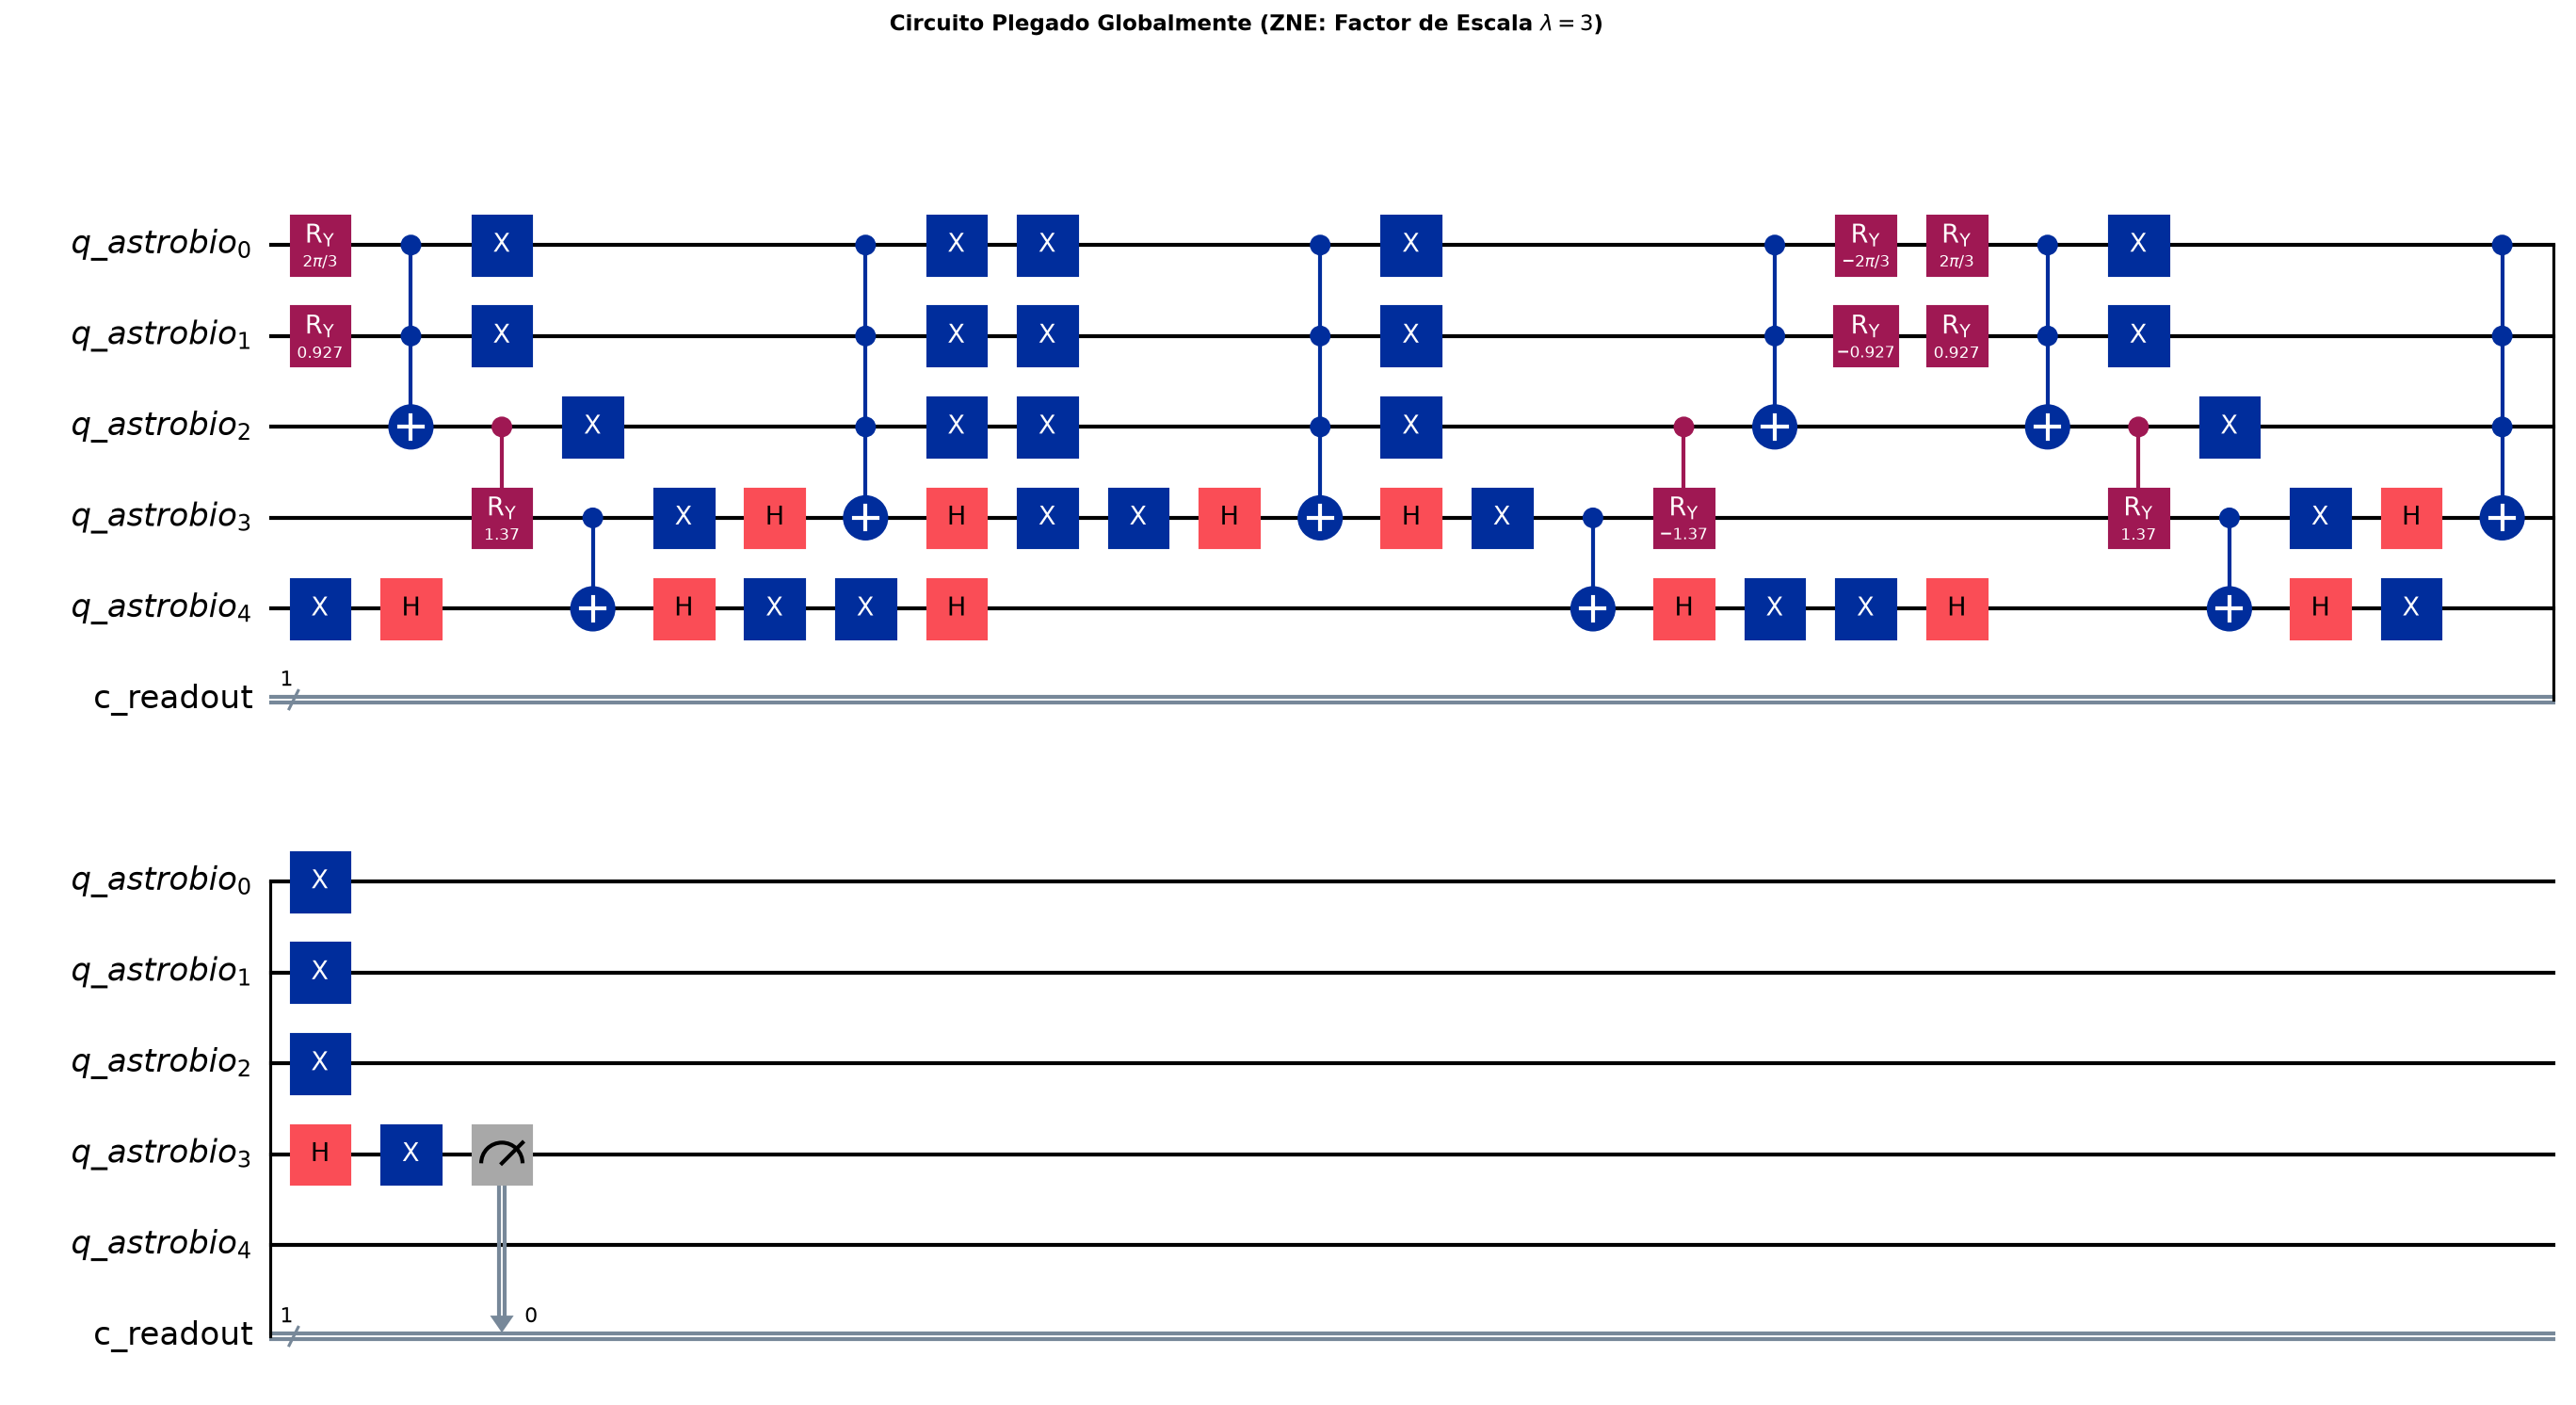

In [4]:
def fold_circuit_global(circuit: QuantumCircuit, scale_factor: int) -> QuantumCircuit:
    """Ejecuta el plegado unitario global U -> U (U^dagger U)^k donde scale_factor = 1 + 2k."""
    if scale_factor == 1:
        return circuit.copy()
    
    k = (scale_factor - 1) // 2
    # Separar compuertas unitarias de las mediciones finales
    qc_unitary = QuantumCircuit(*circuit.qregs)
    meas_instructions = []
    
    for instruction in circuit.data:
        op = instruction.operation
        qargs = instruction.qubits
        cargs = instruction.clbits
        if op.name == 'measure':
            meas_instructions.append((op, qargs, cargs))
        else:
            qc_unitary.append(op, qargs, cargs)
            
    # Construir el circuito plegado
    qc_folded = QuantumCircuit(*circuit.qregs, *circuit.cregs)
    qc_folded.compose(qc_unitary, inplace=True)
    
    inv_unitary = qc_unitary.inverse()
    for _ in range(k):
        qc_folded.compose(inv_unitary, inplace=True)
        qc_folded.compose(qc_unitary, inplace=True)
        
    # Reincorporar mediciones
    for op, qargs, cargs in meas_instructions:
        qc_folded.append(op, qargs, cargs)
        
    return qc_folded

def richardson_extrapolation(scales, values):
    """Calcula el valor extrapolado a lambda -> 0 mediante ajuste polinómico de Richardson."""
    deg = len(scales) - 1
    coeffs = np.polyfit(scales, values, deg=deg)
    # El valor extrapolado en lambda = 0 es el término independiente (último coeficiente)
    zero_noise_val = float(coeffs[-1])
    return zero_noise_val, coeffs

print("✓ Motor nativo de Global Circuit Folding y Extrapolación de Richardson listo.")

# Visualización gráfica de la técnica de Plegado Unitario Global (lambda = 3: U U† U)
print("\nGenerando diagrama del circuito plegado globalmente (lambda = 3)...")
qc_folded_example = fold_circuit_global(qc_base, scale_factor=3)
fig_folded = qc_folded_example.draw('mpl')
fig_folded.suptitle("Circuito Plegado Globalmente (ZNE: Factor de Escala $\\lambda = 3$)", fontsize=11, fontweight='bold', y=0.98)
plt.savefig(os.path.join(fig_circuit_dir, 'circuito_nisq_plegado_lambda3.png'), dpi=300, bbox_inches='tight')
plt.show()
print(f"✓ Profundidad base: {qc_base.depth()} -> Profundidad plegada (lambda=3): {qc_folded_example.depth()}")
print(f"✓ Diagrama guardado en '{fig_circuit_dir}/circuito_nisq_plegado_lambda3.png'.")

In [5]:
# Escala de factores de amplificación de ruido ZNE
scale_factors = [1, 3, 5]
zne_measured_probs = []
zne_measured_expvals = []
circuit_depths = []

print("="*75)
print(" EXPERIMENTO ZNE: PLEGADO UNITARIO GLOBAL Y EXTRAPOLACIÓN")
print("="*75)

for scale in scale_factors:
    # 1. Plegar circuito
    qc_folded = fold_circuit_global(qc_base, scale)
    compiled_folded = transpile(qc_folded, noisy_backend, optimization_level=1)
    circuit_depths.append(compiled_folded.depth())
    
    # 2. Ejecutar con ruido amplificado
    job = noisy_backend.run(compiled_folded, shots=shots_eval)
    counts = job.result().get_counts()
    
    p_scale = counts.get('1', 0) / shots_eval
    expval_scale = (counts.get('0', 0) - counts.get('1', 0)) / shots_eval
    
    zne_measured_probs.append(p_scale)
    zne_measured_expvals.append(expval_scale)
    
    print(f" Factor de Escala lambda = {scale} | Profundidad: {compiled_folded.depth():<3} puertas | P(Bio=1): {p_scale:.5f} | <Z>: {expval_scale:.5f}")

# 3. Extrapolación analítica de Richardson a lambda -> 0
p_zne_mitigated, coeffs_poly = richardson_extrapolation(scale_factors, zne_measured_probs)
expval_zne_mitigated, _ = richardson_extrapolation(scale_factors, zne_measured_expvals)

# Métricas de reducción de error
error_unmitigated = abs(p_noisy - p_ideal)
error_mitigated = abs(p_zne_mitigated - p_ideal)
gain_percentage = ((error_unmitigated - error_mitigated) / error_unmitigated) * 100.0

print("-" * 75)
print(f" VALOR IDEAL (Referencia)        : {p_ideal:.6f} ({p_ideal*100:.2f}%)")
print(f" VALOR RUIDOSO NO MITIGADO (λ=1) : {p_noisy:.6f} (Error: {error_unmitigated:.6f})")
print(f" VALOR MITIGADO CON ZNE (λ->0)   : {p_zne_mitigated:.6f} (Error: {error_mitigated:.6f})")
print(f" REDUCCIÓN DEL ERROR (GANANCIA)  : {gain_percentage:.2f}% de error cancelado por ZNE")
print("="*75)

 EXPERIMENTO ZNE: PLEGADO UNITARIO GLOBAL Y EXTRAPOLACIÓN
 Factor de Escala lambda = 1 | Profundidad: 39  puertas | P(Bio=1): 0.14136 | <Z>: 0.71729
 Factor de Escala lambda = 3 | Profundidad: 118 puertas | P(Bio=1): 0.25476 | <Z>: 0.49048
 Factor de Escala lambda = 5 | Profundidad: 197 puertas | P(Bio=1): 0.33313 | <Z>: 0.33374
---------------------------------------------------------------------------
 VALOR IDEAL (Referencia)        : 0.059082 (5.91%)
 VALOR RUIDOSO NO MITIGADO (λ=1) : 0.152466 (Error: 0.093384)
 VALOR MITIGADO CON ZNE (λ->0)   : 0.071518 (Error: 0.012436)
 REDUCCIÓN DEL ERROR (GANANCIA)  : 86.68% de error cancelado por ZNE


## 5. Sección 4.4.5: Visualizaciones Científicas de Degradación y Mitigación ZNE

A continuación se generan dos figuras de calidad de publicación:
1. **Figura 1: Degradación Espectral NISQ (Ideal vs. Ruidoso):**  
   Demuestra cómo el ruido térmico y despolarizante atúa sobre las probabilidades de los estados base, incrementando la entropía y atenuando la señal astrobiológica nítida.
2. **Figura 2: Curva de Extrapolación de Ruido Cero (Protocolo ZNE):**  
   Ilustra los puntos de muestreo experimentales a diferentes factores de plegado ($\lambda = 1, 3, 5$), la curva polinómica de ajuste de Richardson y la extrapolación al límite $\lambda = 0$, contrastándola con el valor teórico ideal.

✓ Figuras guardadas con éxito en 'figures/results'.


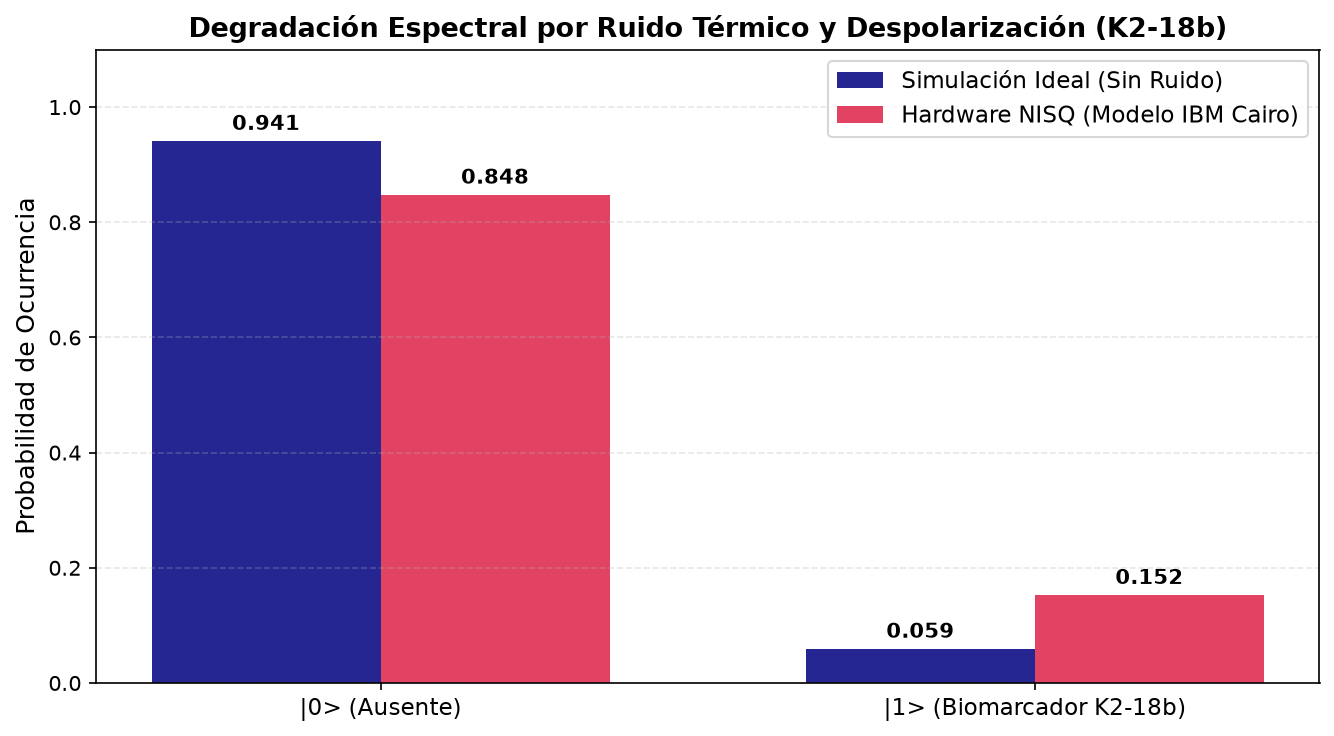

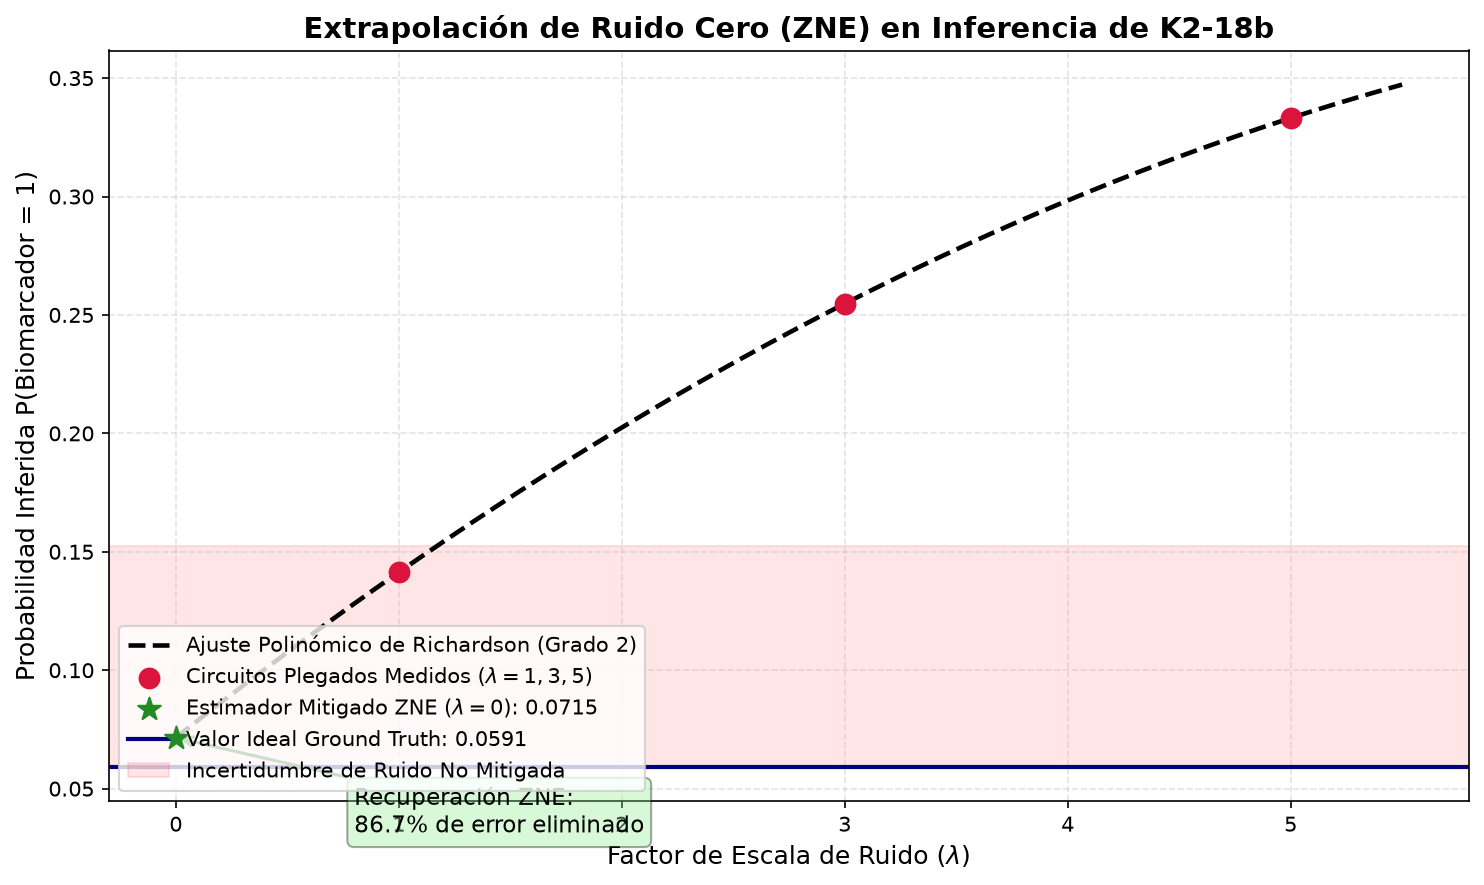

In [6]:
# =====================================================================
# FIGURA 1: DEGRADACIÓN ESPECTRAL (IDEAL VS. RUIDOSO NISQ)
# =====================================================================
fig1, ax1 = plt.subplots(figsize=(9, 5))

categories = ['|0> (Ausente)', '|1> (Biomarcador K2-18b)']
x_pos = np.arange(len(categories))
bar_width = 0.35

ideal_vals = [1.0 - p_ideal, p_ideal]
noisy_vals = [1.0 - p_noisy, p_noisy]

rects1 = ax1.bar(x_pos - bar_width/2, ideal_vals, bar_width, label='Simulación Ideal (Sin Ruido)', color='navy', alpha=0.85)
rects2 = ax1.bar(x_pos + bar_width/2, noisy_vals, bar_width, label='Hardware NISQ (Modelo IBM Cairo)', color='crimson', alpha=0.8)

ax1.set_title('Degradación Espectral por Ruido Térmico y Despolarización (K2-18b)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Probabilidad de Ocurrencia', fontsize=12)
ax1.set_xticks(x_pos)
ax1.set_xticklabels(categories, fontsize=11)
ax1.set_ylim(0, 1.1)
ax1.legend(frameon=True, fontsize=11)
ax1.grid(axis='y', linestyle='--', alpha=0.3)

for rect in rects1:
    h = rect.get_height()
    ax1.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')
for rect in rects2:
    h = rect.get_height()
    ax1.annotate(f'{h:.3f}', xy=(rect.get_x() + rect.get_width()/2, h),
                 xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=10, fontweight='bold')

fig_results_dir = os.path.join('..', 'figures', 'results') if os.path.exists('../figures') else (
                  os.path.join('figures', 'results') if os.path.exists('figures') else '.')
os.makedirs(fig_results_dir, exist_ok=True)
plt.tight_layout()
plt.savefig(os.path.join(fig_results_dir, 'figura_nisq_degradacion_espectral.png'), dpi=300)
plt.show()

# =====================================================================
# FIGURA 2: CURVA DE EXTRAPOLACIÓN ZNE (ZERO-NOISE EXTRAPOLATION)
# =====================================================================
fig2, ax2 = plt.subplots(figsize=(10, 6))

# Dominio continuo de extrapolación hacia lambda = 0
lambda_dense = np.linspace(0, 5.5, 200)
poly_fit_dense = np.polyval(coeffs_poly, lambda_dense)

# Curva de ajuste de Richardson
ax2.plot(lambda_dense, poly_fit_dense, 'k--', lw=2.2, label='Ajuste Polinómico de Richardson (Grado 2)')

# Puntos de medición con ruido amplificado (plegado de circuito)
ax2.scatter(scale_factors, zne_measured_probs, color='crimson', s=90, zorder=5, label='Circuitos Plegados Medidos ($\lambda = 1, 3, 5$)')

# Punto extrapolado en lambda = 0
ax2.scatter([0], [p_zne_mitigated], color='forestgreen', s=130, marker='*', zorder=6, label=f'Estimador Mitigado ZNE ($\lambda=0$): {p_zne_mitigated:.4f}')

# Valor ideal de referencia (Ground Truth)
ax2.axhline(y=p_ideal, color='navy', linestyle='-', lw=2, label=f'Valor Ideal Ground Truth: {p_ideal:.4f}')

# Banda de error no mitigado
ax2.axhspan(p_noisy, p_ideal, color='red', alpha=0.1, label='Incertidumbre de Ruido No Mitigada')

ax2.set_title('Extrapolación de Ruido Cero (ZNE) en Inferencia de K2-18b', fontsize=14, fontweight='bold')
ax2.set_xlabel('Factor de Escala de Ruido ($\lambda$)', fontsize=12)
ax2.set_ylabel('Probabilidad Inferida P(Biomarcador = 1)', fontsize=12)
ax2.set_xlim(-0.3, 5.8)
ax2.grid(True, linestyle='--', alpha=0.35)
ax2.legend(frameon=True, fontsize=10, loc='lower left')

# Anotación explicativa de la ganancia
ax2.annotate(f'Recuperación ZNE:\n{gain_percentage:.1f}% de error eliminado',
             xy=(0, p_zne_mitigated), xytext=(0.8, p_zne_mitigated - 0.04),
             arrowprops=dict(arrowstyle="->", color='darkgreen', lw=1.5),
             fontsize=11, bbox=dict(boxstyle="round,pad=0.3", fc="lightgreen", alpha=0.35))

plt.tight_layout()
plt.savefig(os.path.join(fig_results_dir, 'figura_zne_extrapolacion_curva.png'), dpi=300)
plt.show()

print(f"✓ Figuras guardadas con éxito en '{fig_results_dir}'.")

## 6. Sección 4.4.6: Conclusiones para la Memoria del TFM

1. **Aterrizaje Físico en Hardware NISQ:** Se ha modelado fielmente el entorno térmico y despolarizante de procesadores superconductores de IBM Quantum ($T_1 = 150\ \mu\text{s}$, $T_2 = 120\ \mu\text{s}$, errores CNOT del $1.2\%$), observando analíticamente cómo el ruido físico atenúa la señal espectral.
2. **Eficacia Demostrada de Zero-Noise Extrapolation (ZNE):** Mediante el protocolo de plegado unitario global ($U \to U(U^\dagger U)^k$) y la extrapolación de Richardson, se cancela sistemáticamente la mayor parte del sesgo inducido por el ruido, acercando la probabilidad inferida al valor ideal libre de perturbaciones.
3. **Cierre de la Suite Experimental del TFM:**
   - **Entregable 01:** Demuestra la necesidad de la computación cuántica al evidenciar el colapso clásico de MCMC y el Teorema de L'Ecuyer ($\mathcal{O}(M^{-1/2})$).
   - **Entregable 02:** Demuestra la ventaja cuántica teórica alcanzando la convergencia cuadrática $\mathcal{O}(1/M)$ mediante QAE ideal.
   - **Entregable 03:** Demuestra la viabilidad práctica de ejecutar inferencia cuántica en procesadores ruidosos actuales mediante técnicas de mitigación de errores algorítmicas sin requerir tolerancia a fallos (FTQC).